In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as functional

In [ ]:
class Model(nn.Module):
    #Input Layer (features) --> Hiiden Layer1 (x# neurons) --> HL2 --> output

    def __init__(self,features=10, h1=8,h2=8,output=2):
        super().__init__()
        self.fc1 = nn.Linear(features,h1)
        self.fc2 = nn.Linear(h1,h2)
        self.out = nn.Linear(h2,output)
    
    def forward(self,x):
        x = functional.relu(self.fc1(x))
        x = functional.relu(self.fc2(x))
        x = self.out(x)

        return x



In [ ]:
torch.manual_seed(41)
model = Model()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [ ]:
col_names = [
    "kd_diff",
    "sig_strike_diff",
    "total_strikes_diff",
    "td_diff",
    "ctrl_time_diff",
    "height_diff",
    "weight_diff",
    "reach_diff",
    "age_diff",
    "winrate_diff",
    "winner",
]
data = pd.read_csv("organizedFightStats copy.csv", names=col_names, header=0)
data.head()

,kd_diff,sig_strike_diff,total_strikes_diff,td_diff,ctrl_time_diff,height_diff,weight_diff,reach_diff,age_diff,winrate_diff,winner
0,-0.40,49.2,93.8,0.6,19.2,4,0,0,1,-0.104775,0
1,-0.10,14.8,16.8,-1.0,-29.5,5,0,6,13,-0.230159,0
2,0.25,1.0,16.0,-1.0,-22.5,-2,0,-1,12,-0.072222,0
3,-0.60,2.6,29.0,0.0,30.6,2,0,2,-1,0.144886,1
4,0.20,14.0,-42.0,-1.0,-302.0,3,-19,6,-2,-0.014286,0


In [ ]:
features = [
    "kd_diff",
    "sig_strike_diff",
    "total_strikes_diff",
    "td_diff",
    "ctrl_time_diff",
    "height_diff",
    "weight_diff",
    "reach_diff",
    "age_diff",
    "winrate_diff"
]
X = data[features]
Y = data.winner

In [ ]:
#Convert to np arrays
X=X.values
Y = Y.values

In [ ]:
from sklearn.model_selection import train_test_split as tts

In [ ]:
X_train,X_test,Y_train,Y_test = tts(X,Y,test_size = 0.2, random_state=41)


In [ ]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

Y_train = torch.LongTensor(Y_train)
Y_test = torch.LongTensor(Y_test)



In [ ]:
# Model to measure error
criterion = nn.CrossEntropyLoss()

# Adam Optimizer, learning rate
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)


In [ ]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=10, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=2, bias=True)
)>

In [ ]:
#Training

#Iterations

iterations = 10000

losses = []

for i in range (iterations):
    # -> Foward
    y_pred = model.forward(X_train)

    # Measure loss starts high goes down

    loss = criterion(y_pred,Y_train)

    losses.append(loss.detach().numpy())

    #print every 10
    if i % 10 == 0:
        print(f"Iteration: {i} and loss: {loss}")
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


Iteration: 0 and loss: 4.868471145629883
Iteration: 10 and loss: 1.093766689300537
Iteration: 20 and loss: 0.7700521349906921
Iteration: 30 and loss: 0.7005959749221802
Iteration: 40 and loss: 0.6745100617408752
Iteration: 50 and loss: 0.6656162142753601
Iteration: 60 and loss: 0.6625691652297974
Iteration: 70 and loss: 0.6611923575401306
Iteration: 80 and loss: 0.6598305106163025
Iteration: 90 and loss: 0.6583695411682129
Iteration: 100 and loss: 0.6571529507637024
Iteration: 110 and loss: 0.6560545563697815
Iteration: 120 and loss: 0.6551162600517273
Iteration: 130 and loss: 0.6542602777481079
Iteration: 140 and loss: 0.6534630656242371
Iteration: 150 and loss: 0.6527044773101807
Iteration: 160 and loss: 0.6519230604171753
Iteration: 170 and loss: 0.6511347889900208
Iteration: 180 and loss: 0.6503381729125977
Iteration: 190 and loss: 0.6495106220245361
Iteration: 200 and loss: 0.6486829519271851
Iteration: 210 and loss: 0.6478297710418701
Iteration: 220 and loss: 0.6469747424125671
I

Text(0, 0.5, 'Loss/error')

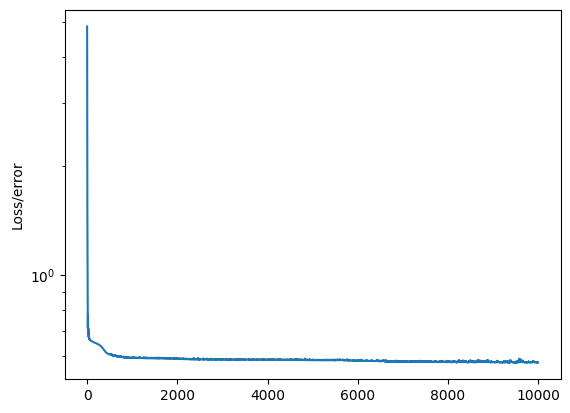

In [ ]:

plt.semilogy(range(iterations),losses)
plt.ylabel("Loss/error")


In [ ]:

with torch.no_grad():
    y_eval = model.forward(X_test)
    loss = criterion(y_eval,Y_test)

loss

tensor(0.6815)

In [ ]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)

        print(f"{i+1}.  {str(y_val)} \t {Y_test[i]}")

        if (y_val.argmax().item() == Y_test[i]):
            correct += 1

correct/len(X_test)

1.  tensor([1.5587, 2.8394]) 	 1
2.  tensor([ 1.2889, -0.6314]) 	 0
3.  tensor([-0.5091,  2.4086]) 	 0
4.  tensor([3.9401, 3.2553]) 	 1
5.  tensor([0.6448, 0.0176]) 	 1
6.  tensor([ 1.3143, -0.1352]) 	 0
7.  tensor([1.8496, 4.0625]) 	 1
8.  tensor([2.3311, 0.9663]) 	 1
9.  tensor([1.9973, 2.7261]) 	 0
10.  tensor([3.0632, 2.2660]) 	 0
11.  tensor([0.9774, 2.3460]) 	 1
12.  tensor([0.6034, 1.1765]) 	 0
13.  tensor([2.6697, 3.9364]) 	 1
14.  tensor([1.8587, 2.2271]) 	 1
15.  tensor([1.5138, 1.1530]) 	 0
16.  tensor([-0.2536,  0.8188]) 	 0
17.  tensor([0.2054, 0.9000]) 	 0
18.  tensor([0.6995, 0.0521]) 	 0
19.  tensor([0.6285, 1.7098]) 	 1
20.  tensor([-0.1999,  0.7381]) 	 0
21.  tensor([ 1.0150, -0.3005]) 	 0
22.  tensor([0.0323, 0.7752]) 	 0
23.  tensor([0.2730, 0.3729]) 	 0
24.  tensor([0.4581, 0.1176]) 	 1
25.  tensor([0.0365, 0.8325]) 	 0
26.  tensor([1.9820, 2.6355]) 	 1
27.  tensor([ 1.1824, -0.3260]) 	 0
28.  tensor([-0.2060,  0.7465]) 	 1
29.  tensor([-0.2733,  0.8081]) 	 1
30.  

0.6399406087602079